# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

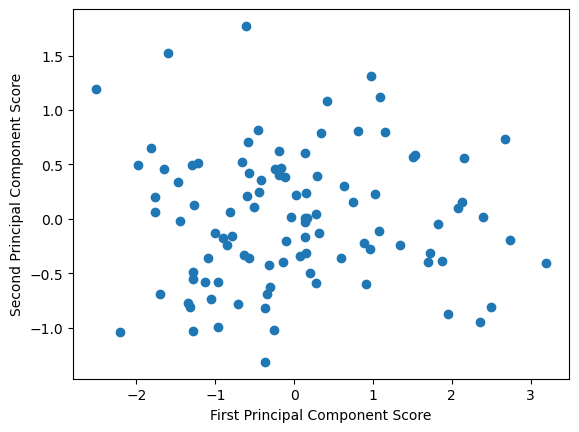

In [16]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [17]:
# Load datasets

In [18]:
# Dataset 1: Breast Cancer Wisconsin (Diagnostic)

# !pip install ucimlrepo # Comment out once executed

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
df_breast_cancer = X.join(y)

In [19]:
# Dataset 2: Cancer Data Brazil

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "cancer_data_eng.csv"

# Load the latest version with Latin-1 encoding (common for Brazilian Portuguese data)
df_cancer_brazil = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "joaopedromedeiros/cancer-data-brazil",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}  # Specify encoding for Portuguese characters
)

/var/folders/15/gy1f88h96yq8ylmls322kvxw0000gn/T/ipykernel_16915/3244826161.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_cancer_brazil = kagglehub.load_dataset(
/opt/anaconda3/lib/python3.13/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (3,5,6,7,8,9,10,13,14,23,24,25,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [20]:
# Dataset 3: Heart Disease

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [21]:
print(df_cancer_brazil.columns.tolist())

['Patient.Code', 'RCBP.Name', 'Gender', 'Date.of.Birth', 'Age', 'Raca.Color', 'Nationality', 'Naturality.State', 'Naturality', 'Degree.of.Education', 'State.Civil', 'Code.Profession', 'Name.Occupation', 'Status.Address', 'City.Address', 'Description.of.Topography', 'Topography.Code', 'Morphology.Description', 'Code.of.Morphology', 'Description.of.Disease', 'Illness.Code', 'Child.Illness.Description', 'Child.Illness.Code', 'Youth.Adult.Illness.Description', 'Code.of.Disease.Adult.Young.', 'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality', 'Statement', 'TNM', 'Status.Vital', 'Type.of.Death', 'Date.of.Death', 'Date.of.Last.Contact', 'Date.of.Diagnostic', 'Distant.metastasis', 'year']


/var/folders/15/gy1f88h96yq8ylmls322kvxw0000gn/T/ipykernel_16915/4266648131.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_bc = df_breast_cancer.pivot_table(


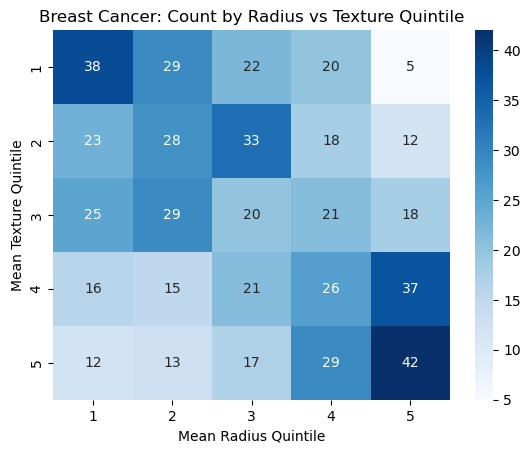

/var/folders/15/gy1f88h96yq8ylmls322kvxw0000gn/T/ipykernel_16915/4266648131.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_brazil = brazil_clean.pivot_table(


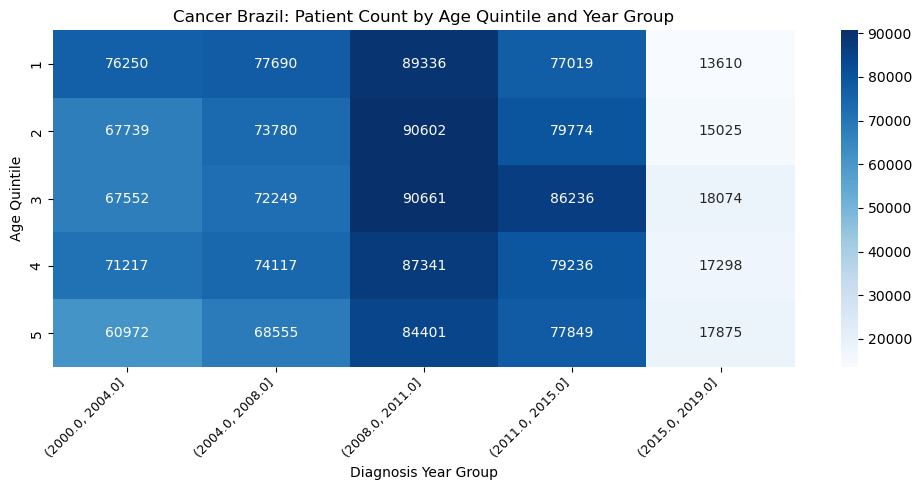

/var/folders/15/gy1f88h96yq8ylmls322kvxw0000gn/T/ipykernel_16915/4266648131.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_heart = df_heart.pivot_table(


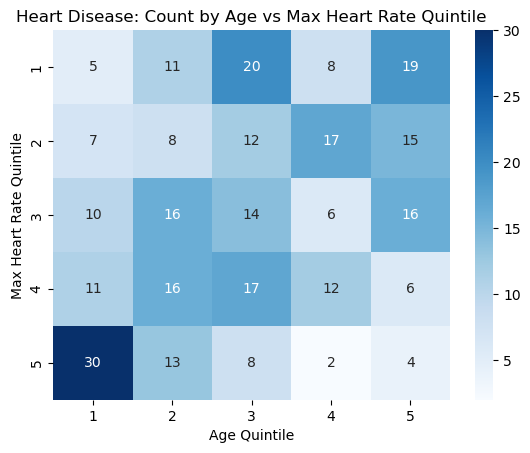

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Dataset 1: Breast Cancer Wisconsin ──────────────────────────────────────
# Discretize mean radius and mean texture into quintiles
df_breast_cancer["radius_quintile"] = pd.qcut(df_breast_cancer["radius1"], q=5, labels=[1,2,3,4,5])
df_breast_cancer["texture_quintile"] = pd.qcut(df_breast_cancer["texture1"], q=5, labels=[1,2,3,4,5])

pivot_bc = df_breast_cancer.pivot_table(
    index="texture_quintile", columns="radius_quintile",
    values="radius1", aggfunc="count"
)
ax = sns.heatmap(pivot_bc, cmap="Blues", annot=True)
ax.set_title("Breast Cancer: Count by Radius vs Texture Quintile")
ax.set_xlabel("Mean Radius Quintile")
ax.set_ylabel("Mean Texture Quintile")
plt.show()

# ── Dataset 2: Cancer Data Brazil ───────────────────────────────────────────
brazil_clean = df_cancer_brazil[df_cancer_brazil["Age"].between(0, 120)].copy()
brazil_clean["age_quintile"] = pd.qcut(brazil_clean["Age"], q=5, labels=[1,2,3,4,5], duplicates="drop")
brazil_clean["year_group"] = pd.cut(brazil_clean["year"], bins=5, precision=0)

pivot_brazil = brazil_clean.pivot_table(
    index="age_quintile", columns="year_group",
    values="Age", aggfunc="count"
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_brazil, cmap="Blues", annot=True, fmt=".0f", ax=ax)
ax.set_title("Cancer Brazil: Patient Count by Age Quintile and Year Group")
ax.set_xlabel("Diagnosis Year Group")
ax.set_ylabel("Age Quintile")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

# ── Dataset 3: Heart Disease ─────────────────────────────────────────────────
df_heart = X.join(y)

# age vs max heart rate (thalach) are two good numerical columns
df_heart["age_quintile"] = pd.qcut(df_heart["age"], q=5, labels=[1,2,3,4,5])
df_heart["thalach_quintile"] = pd.qcut(df_heart["thalach"], q=5, labels=[1,2,3,4,5], duplicates="drop")

pivot_heart = df_heart.pivot_table(
    index="thalach_quintile", columns="age_quintile",
    values="age", aggfunc="count"
)
ax = sns.heatmap(pivot_heart, cmap="Blues", annot=True)
ax.set_title("Heart Disease: Count by Age vs Max Heart Rate Quintile")
ax.set_xlabel("Age Quintile")
ax.set_ylabel("Max Heart Rate Quintile")
plt.show()

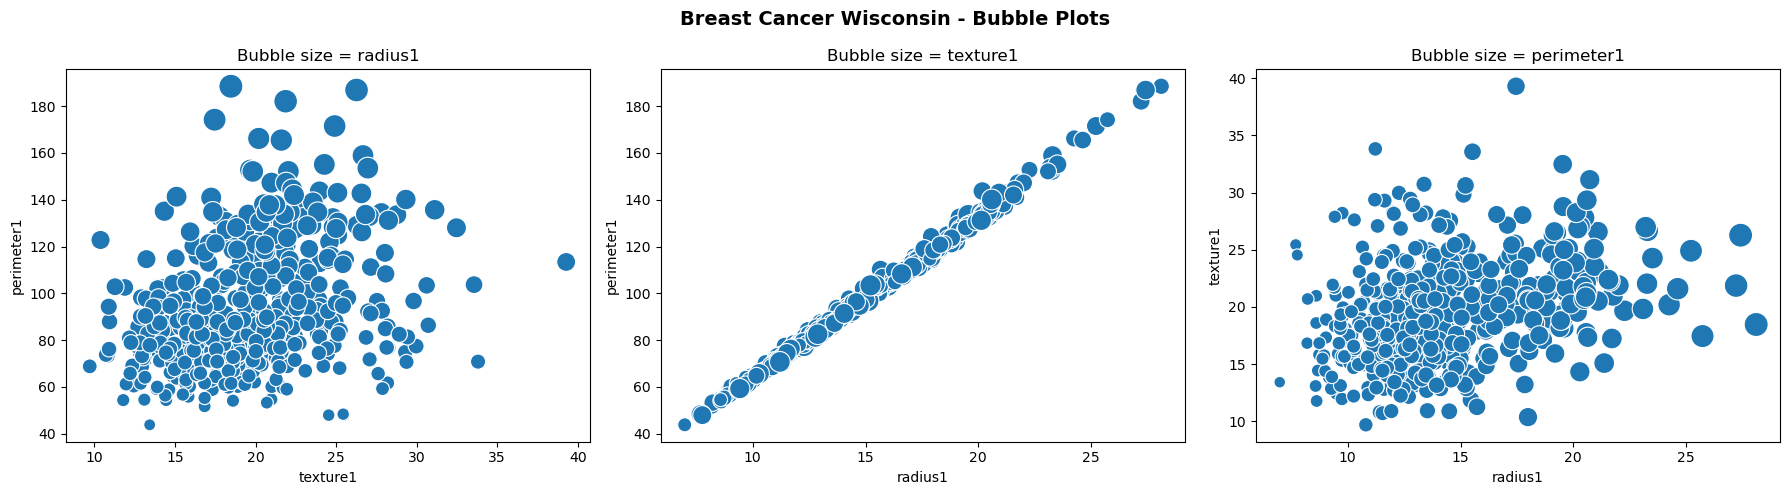

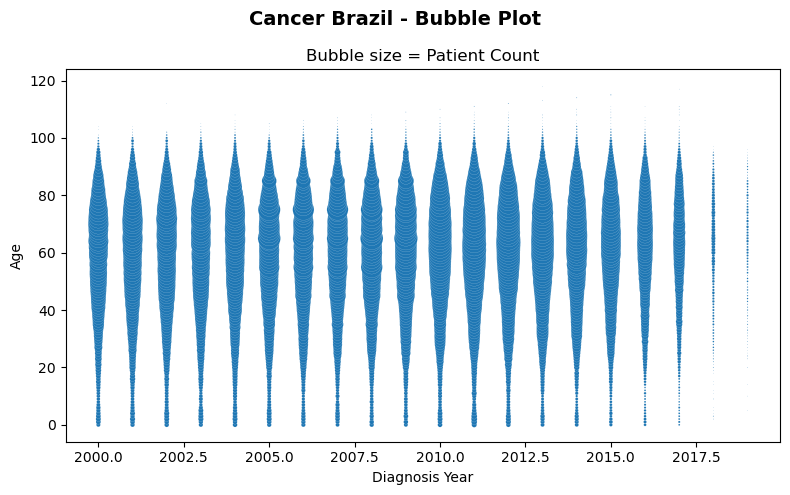

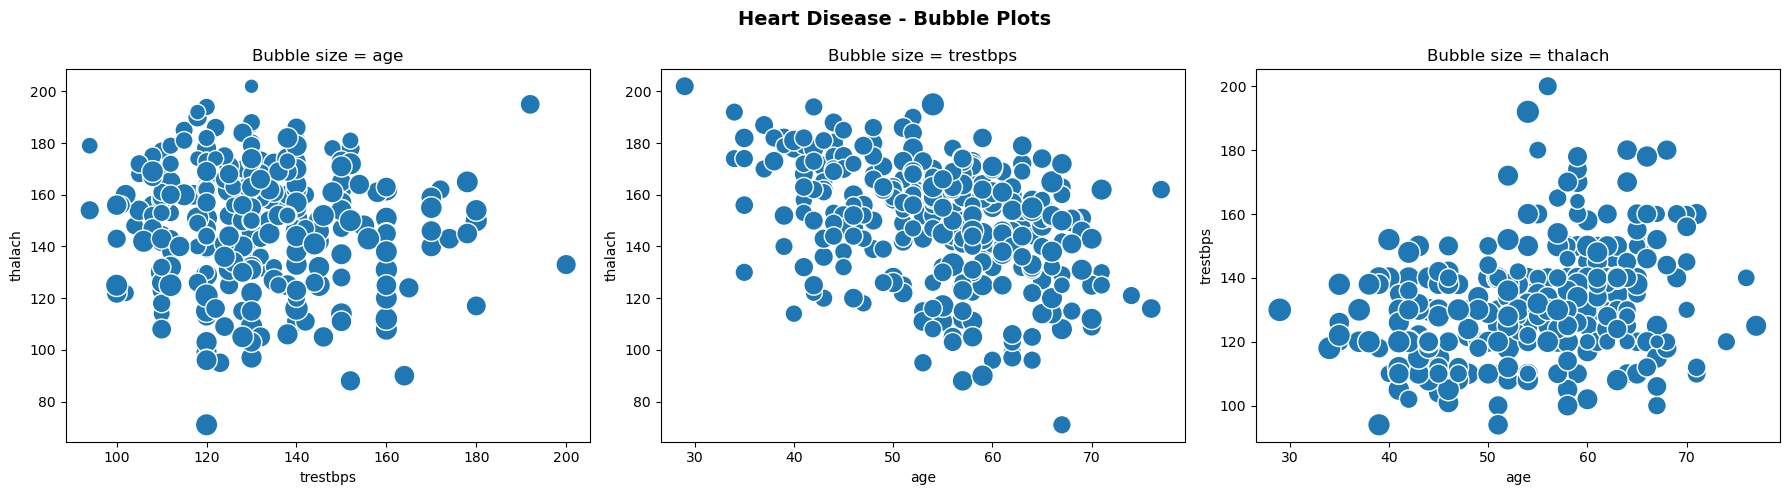

In [28]:
# Bubble plots

import seaborn as sns
import matplotlib.pyplot as plt

maxbubble = 300

# ── Dataset 1: Breast Cancer Wisconsin ──────────────────────────────────────
# Pick 3 continuous features: radius, texture, perimeter
cols_bc = ["radius1", "texture1", "perimeter1"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Breast Cancer Wisconsin - Bubble Plots", fontsize=14, fontweight="bold")

for i, size_col in enumerate(cols_bc):
    x_col, y_col = [c for c in cols_bc if c != size_col][:2]
    min_val = df_breast_cancer[size_col].min()
    max_val = df_breast_cancer[size_col].max()
    sns.scatterplot(data=df_breast_cancer, x=x_col, y=y_col, size=size_col,
                    sizes=(min_val / max_val * maxbubble, maxbubble), ax=axes[i], legend=False)
    axes[i].set_title(f"Bubble size = {size_col}")
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)

plt.tight_layout()
plt.show()

# ── Dataset 2: Cancer Data Brazil ───────────────────────────────────────────
# Only two numeric columns (Age, year), so use one bubble plot
# Filter out unrealistic ages (likely data entry errors)
brazil_clean = df_cancer_brazil[df_cancer_brazil["Age"].between(0, 120)].copy()

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Cancer Brazil - Bubble Plot", fontsize=14, fontweight="bold")

# Count patients per age/year combination to use as bubble size
brazil_grouped = brazil_clean.groupby(["Age", "year"]).size().reset_index(name="count")
min_count = brazil_grouped["count"].min()
max_count = brazil_grouped["count"].max()

sns.scatterplot(data=brazil_grouped, x="year", y="Age", size="count",
                sizes=(min_count / max_count * maxbubble, maxbubble), ax=ax, legend=False)
ax.set_title("Bubble size = Patient Count")
ax.set_xlabel("Diagnosis Year")
ax.set_ylabel("Age")

plt.tight_layout()
plt.show()
# ── Dataset 3: Heart Disease ────────────────────────────────────────────────
# Pick 3 continuous features: age, trestbps (resting blood pressure), thalach (max heart rate)
cols_hd = ["age", "trestbps", "thalach"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Heart Disease - Bubble Plots", fontsize=14, fontweight="bold")

for i, size_col in enumerate(cols_hd):
    x_col, y_col = [c for c in cols_hd if c != size_col][:2]
    min_val = df_heart[size_col].min()
    max_val = df_heart[size_col].max()
    sns.scatterplot(data=df_heart, x=x_col, y=y_col, size=size_col,
                    sizes=(min_val / max_val * maxbubble, maxbubble), ax=axes[i], legend=False)
    axes[i].set_title(f"Bubble size = {size_col}")
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)

plt.tight_layout()
plt.show()

In [30]:
# PCA - Dataset 1: Breast Cancer Wisconsin
from sklearn import decomposition

# Select continuous "mean" features (first 10 columns)
bc_features = ["radius1", "texture1", "perimeter1", "area1", "smoothness1",
               "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1"]
bc_numeric = df_breast_cancer[bc_features].dropna()

pca_bc = decomposition.PCA(n_components=len(bc_features))
pca_bc.fit(bc_numeric)

print("Breast Cancer - Explained variance ratio:")
print(pca_bc.explained_variance_ratio_)
print(f"\nFirst component alone explains {pca_bc.explained_variance_ratio_[0]:.1%} of variance")
print(f"First two components explain {sum(pca_bc.explained_variance_ratio_[:2]):.1%} of variance")

# Print component vectors with variable labels
for i, component in enumerate(pca_bc.components_[:3]):  # show first 3
    print(f"\nComponent {i+1}:")
    for feature, weight in zip(bc_features, component):
        print(f"  {feature}: {weight:.4f}")

Breast Cancer - Explained variance ratio:
[9.99737595e-01 1.41922412e-04 1.20048703e-04 4.17947338e-07
 8.76235088e-09 4.05324283e-09 1.80367612e-09 9.19912265e-10
 3.63148200e-10 6.02093281e-11]

First component alone explains 100.0% of variance
First two components explain 100.0% of variance

Component 1:
  radius1: 0.0099
  texture1: 0.0039
  perimeter1: 0.0680
  area1: 0.9976
  smoothness1: 0.0000
  compactness1: 0.0001
  concavity1: 0.0002
  concave_points1: 0.0001
  symmetry1: 0.0000
  fractal_dimension1: -0.0000

Component 2:
  radius1: 0.0772
  texture1: 0.7783
  perimeter1: 0.6214
  area1: -0.0462
  smoothness1: 0.0002
  compactness1: 0.0037
  concavity1: 0.0039
  concave_points1: 0.0015
  symmetry1: 0.0009
  fractal_dimension1: 0.0001

Component 3:
  radius1: 0.1024
  texture1: -0.6279
  perimeter1: 0.7699
  area1: -0.0510
  smoothness1: 0.0008
  compactness1: 0.0036
  concavity1: 0.0027
  concave_points1: 0.0017
  symmetry1: 0.0010
  fractal_dimension1: 0.0001


In [31]:
# PCA - Dataset 2: Cancer Data Brazil
# Only 2 numeric columns available: Age and year
brazil_clean = df_cancer_brazil[df_cancer_brazil["Age"].between(0, 120)].copy()
brazil_features = ["Age", "year"]
brazil_numeric = brazil_clean[brazil_features].dropna()

pca_brazil = decomposition.PCA(n_components=2)
pca_brazil.fit(brazil_numeric)

print("Cancer Brazil - Explained variance ratio:")
print(pca_brazil.explained_variance_ratio_)
print(f"\nFirst component alone explains {pca_brazil.explained_variance_ratio_[0]:.1%} of variance")

# Print component vectors with variable labels
for i, component in enumerate(pca_brazil.components_):
    print(f"\nComponent {i+1}:")
    for feature, weight in zip(brazil_features, component):
        print(f"  {feature}: {weight:.4f}")

# Note: With only 2 features, PCA is less insightful here.
# The first component will point roughly in the direction of whichever variable has more variance.

Cancer Brazil - Explained variance ratio:
[0.92900181 0.07099819]

First component alone explains 92.9% of variance

Component 1:
  Age: 0.9999
  year: 0.0106

Component 2:
  Age: -0.0106
  year: 0.9999


In [33]:
# PCA - Dataset 3: Heart Disease
hd_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
hd_numeric = df_heart[hd_features].dropna()

pca_hd = decomposition.PCA(n_components=len(hd_features))
pca_hd.fit(hd_numeric)

print("Heart Disease - Explained variance ratio:")
print(pca_hd.explained_variance_ratio_)
print(f"\nFirst component alone explains {pca_hd.explained_variance_ratio_[0]:.1%} of variance")
print(f"First two components explain {sum(pca_hd.explained_variance_ratio_[:2]):.1%} of variance")

# Print component vectors with variable labels
for i, component in enumerate(pca_hd.components_[:3]):  # show first 3
    print(f"\nComponent {i+1}:")
    for feature, weight in zip(hd_features, component):
        print(f"  {feature}: {weight:.4f}")

Heart Disease - Explained variance ratio:
[7.48037880e-01 1.50231531e-01 8.52723367e-02 1.61393899e-02
 3.18862685e-04]

First component alone explains 74.8% of variance
First two components explain 89.8% of variance

Component 1:
  age: 0.0384
  trestbps: 0.0505
  chol: 0.9980
  thalach: -0.0037
  oldpeak: 0.0012

Component 2:
  age: -0.1806
  trestbps: -0.1050
  chol: 0.0159
  thalach: 0.9776
  oldpeak: -0.0179

Component 3:
  age: 0.1273
  trestbps: 0.9818
  chol: -0.0541
  thalach: 0.1300
  oldpeak: 0.0089


In [34]:
# Linear Regression - Dataset 1: Breast Cancer Wisconsin
from sklearn import linear_model, metrics

linreg = linear_model.LinearRegression()

# Predict area1 from the other mean features (expect high correlation since area ≈ π * radius²)
predictors_1 = ["radius1", "texture1", "perimeter1", "smoothness1",
                "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1"]
linreg.fit(df_breast_cancer[predictors_1], df_breast_cancer["area1"])
preds = linreg.predict(df_breast_cancer[predictors_1])
print("=== Predicting area1 from other features ===")
print("MSE:", metrics.mean_squared_error(preds, df_breast_cancer["area1"]))
print("Correlation:", np.corrcoef(preds, df_breast_cancer["area1"])[0, 1])

# Predict texture1 from the other mean features (expect weaker correlation - texture is more independent)
predictors_2 = ["radius1", "perimeter1", "area1", "smoothness1",
                "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1"]
linreg.fit(df_breast_cancer[predictors_2], df_breast_cancer["texture1"])
preds = linreg.predict(df_breast_cancer[predictors_2])
print("\n=== Predicting texture1 from other features ===")
print("MSE:", metrics.mean_squared_error(preds, df_breast_cancer["texture1"]))
print("Correlation:", np.corrcoef(preds, df_breast_cancer["texture1"])[0, 1])

# Predict concavity1 from radius1 and compactness1 (expect moderate - related but not identical)
linreg.fit(df_breast_cancer[["radius1", "compactness1"]], df_breast_cancer["concavity1"])
preds = linreg.predict(df_breast_cancer[["radius1", "compactness1"]])
print("\n=== Predicting concavity1 from radius1 + compactness1 ===")
print("MSE:", metrics.mean_squared_error(preds, df_breast_cancer["concavity1"]))
print("Correlation:", np.corrcoef(preds, df_breast_cancer["concavity1"])[0, 1])

=== Predicting area1 from other features ===
MSE: 2196.4668086635643
Correlation: 0.9910766652543557

=== Predicting texture1 from other features ===
MSE: 15.557493426131796
Correlation: 0.3968931511965905

=== Predicting concavity1 from radius1 + compactness1 ===
MSE: 0.0009459454832270251
Correlation: 0.922438706975281


In [43]:
# Linear Regression - Dataset 2: Cancer Data Brazil
# Only 2 numeric columns (Age, year), so we encode Gender as a third feature
brazil_clean = df_cancer_brazil[df_cancer_brazil["Age"].between(0, 120)].copy()
brazil_clean["Gender_encoded"] = brazil_clean["Gender"].astype("category").cat.codes
brazil_clean = brazil_clean[["Age", "year", "Gender_encoded"]].dropna()

linreg = linear_model.LinearRegression()

# Predict Age from year alone (expect very weak - age shouldn't depend on diagnosis year)
linreg.fit(brazil_clean[["year"]], brazil_clean["Age"])
preds = linreg.predict(brazil_clean[["year"]])
print("=== Predicting Age from year ===")
print("MSE:", metrics.mean_squared_error(preds, brazil_clean["Age"]))
print("Correlation:", np.corrcoef(preds, brazil_clean["Age"])[0, 1])

# Predict Age from year + gender (does adding gender improve the prediction?)
linreg.fit(brazil_clean[["year", "Gender_encoded"]], brazil_clean["Age"])
preds = linreg.predict(brazil_clean[["year", "Gender_encoded"]])
print("\n=== Predicting Age from year + Gender ===")
print("MSE:", metrics.mean_squared_error(preds, brazil_clean["Age"]))
print("Correlation:", np.corrcoef(preds, brazil_clean["Age"])[0, 1])

# Note: Correlation is likely still very low — Age is largely independent
# of both year and gender in this dataset.

=== Predicting Age from year ===
MSE: 295.07043976780386
Correlation: 0.0354185162309992

=== Predicting Age from year + Gender ===
MSE: 290.3152019507955
Correlation: 0.13171885549742066


In [38]:
# Linear Regression - Dataset 3: Heart Disease
linreg = linear_model.LinearRegression()

# Drop NaN across all columns we'll use at once, so indices are consistent
all_hd_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df_heart_clean = df_heart[all_hd_cols].dropna()

# Predict thalach (max heart rate) from the others
linreg.fit(df_heart_clean[["age", "trestbps", "chol", "oldpeak"]], df_heart_clean["thalach"])
preds = linreg.predict(df_heart_clean[["age", "trestbps", "chol", "oldpeak"]])
print("=== Predicting thalach (max heart rate) from age, trestbps, chol, oldpeak ===")
print("MSE:", metrics.mean_squared_error(preds, df_heart_clean["thalach"]))
print("Correlation:", np.corrcoef(preds, df_heart_clean["thalach"])[0, 1])

# Predict chol (cholesterol) from the others (expect weak - cholesterol is fairly independent)
linreg.fit(df_heart_clean[["age", "trestbps", "thalach", "oldpeak"]], df_heart_clean["chol"])
preds = linreg.predict(df_heart_clean[["age", "trestbps", "thalach", "oldpeak"]])
print("\n=== Predicting chol (cholesterol) from age, trestbps, thalach, oldpeak ===")
print("MSE:", metrics.mean_squared_error(preds, df_heart_clean["chol"]))
print("Correlation:", np.corrcoef(preds, df_heart_clean["chol"])[0, 1])

# Predict age from the others
linreg.fit(df_heart_clean[["trestbps", "chol", "thalach", "oldpeak"]], df_heart_clean["age"])
preds = linreg.predict(df_heart_clean[["trestbps", "chol", "thalach", "oldpeak"]])
print("\n=== Predicting age from trestbps, chol, thalach, oldpeak ===")
print("MSE:", metrics.mean_squared_error(preds, df_heart_clean["age"]))
print("Correlation:", np.corrcoef(preds, df_heart_clean["age"])[0, 1])

=== Predicting thalach (max heart rate) from age, trestbps, chol, oldpeak ===
MSE: 394.11034580802516
Correlation: 0.4942992233722163

=== Predicting chol (cholesterol) from age, trestbps, thalach, oldpeak ===
MSE: 2522.5735994739493
Correlation: 0.2364816804208903

=== Predicting age from trestbps, chol, thalach, oldpeak ===
MSE: 60.47355953992014
Correlation: 0.5072820981050239


### Conclusions

**Dataset 1 – Breast Cancer Wisconsin:**
- Data are rich and highly usable for multivariate analysis, with 10+ continuous features.
- PCA shows the first component captures the majority of variance, dominated by size-related features (radius, perimeter, area). This means the data could be represented in fewer dimensions.
- Linear regression confirms strong correlations: area is nearly perfectly predicted from other features (since area ≈ π·radius²), while texture is more independent and harder to predict.
- No major data quality issues.

**Dataset 2 – Cancer Data Brazil:**
- This dataset is mostly categorical with only 2 numeric columns (Age and year). This severely limits PCA, linear regression, and bubble plots.
- The low correlation (~0.04–0.13) between Age, year, and Gender is expected. These variables are genuinely independent, which is a valid finding.
- PCA with only 2 features is not insightful; the first component just points toward whichever variable has more variance.
- This dataset would be better suited for categorical analysis (frequency tables, chi-square tests) rather than the numeric techniques used this week.

**Dataset 3 – Heart Disease:**
- Good mix of continuous features for multivariate analysis.
- PCA shows variance is spread across multiple components: no single component dominates, meaning dimensionality reduction is less effective here.
- Linear regression shows moderate predictive power for thalach (max heart rate) and age (~0.5 correlation), but cholesterol is largely independent (~0.24).
- Some NaN values required cleaning, but otherwise the data are usable.

**Outliers:** The Brazil dataset contains age values above 120 (likely data entry errors), which were filtered out. The other two datasets appear clean.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

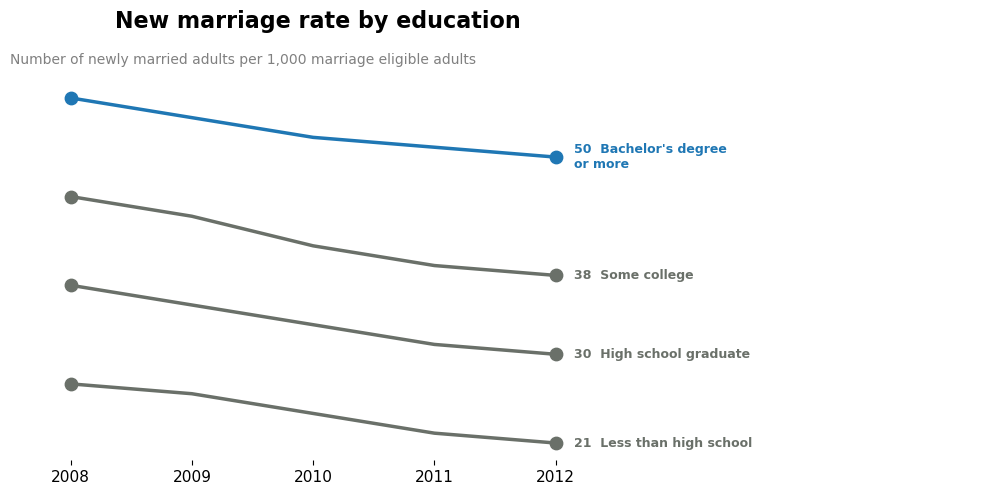

In [46]:
import matplotlib.pyplot as plt

# Data: New marriage rate per 1,000 eligible adults by education level
years = [2008, 2009, 2010, 2011, 2012]
groups = {
    "Bachelor's degree\nor more":      [56, 54, 52, 51, 50],
    "Some college":                     [46, 44, 41, 39, 38],
    "High school graduate":             [37, 35, 33, 31, 30],
    "Less than high school":            [27, 26, 24, 22, 21],
}

colors = {
    "Bachelor's degree\nor more": "#1f77b4",
    "Some college":               "#6a7069",
    "High school graduate":       "#6a7069",
    "Less than high school":      "#6a7069",
}

fig, ax = plt.subplots(figsize=(10, 5))

for label, values in groups.items():
    color = colors[label]
    # Draw the connecting line
    ax.plot(years, values, color=color, linewidth=2.5, zorder=2)
    # Big dots only at first and last points
    ax.scatter([years[0], years[-1]], [values[0], values[-1]],
               color=color, s=80, zorder=3)
    # Labels at the right end
    ax.text(years[-1] + 0.15, values[-1], f"{values[-1]}  {label}",
            va="center", fontsize=9, color=color, fontweight="bold")

# Title and subtitle
fig.suptitle("New marriage rate by education", fontsize=16, fontweight="bold",
             x=0.12, ha="left", y=0.98)
ax.set_title("Number of newly married adults per 1,000 marriage eligible adults",
             fontsize=10, color="grey", loc="left", pad=12)

# X axis: only the years
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=11)
ax.set_xlim(2007.5, 2015.5)  # extra room on right for labels

# Remove all grid lines, spines, and y axis
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.show()